# 1. Load the clean data

In [20]:
import numpy as np
import pandas as pd
data_clean=pd.read_csv("cleaned_dataset.csv")
data_clean

,ClosePrice,Latitude,Longitude,LivingArea,CountyOrParish,ParkingTotal,PropertySubType,LotSizeAcres,YearBuilt,StreetNumberNumeric,...,BedroomsTotal,StateOrProvince,FireplaceYN,LotSizeArea,PostalCode,LotSizeSquareFeet,date_ym,PropertyType_Residential,PropertyType_ResidentialIncome,PropertyType_ResidentialLease
0,399500.0,34.715717,-117.510439,213915.0,San Bernardino,2.0,10,4.9100,2007.0,7162.0,...,3.0,CA,0,213915.0,92301,213915.0,2025-05-01,True,False,False
1,6500.0,33.475311,-117.708995,3870.0,Orange,2.0,16,0.0888,1972.0,33581.0,...,2.0,CA,1,3870.0,92629,3870.0,2025-05-01,False,False,True
2,1800000.0,33.899427,-117.977995,7740.0,Orange,3.0,16,0.1777,2003.0,2856.0,...,5.0,CA,1,7740.0,92833,7740.0,2025-05-01,True,False,False
3,1200000.0,34.095980,-118.221993,4697.0,Los Angeles,2.0,16,0.1078,1940.0,1050.0,...,2.0,CA,1,4697.0,90065,4697.0,2025-05-01,True,False,False
4,3200.0,33.773119,-116.343788,1581.0,Riverside,2.0,4,0.0363,2014.0,621.0,...,4.0,CA,0,1581.0,92211,1581.0,2025-05-01,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232946,21500000.0,37.854648,-121.961587,935669.0,Contra Costa,24.0,16,21.4800,2010.0,7.0,...,10.0,CA,1,935669.0,94507,935669.0,2026-05-01,True,False,False
232947,1650.0,33.860363,-116.555055,436.0,Riverside,3.0,4,0.0100,1982.0,2810.0,...,1.0,CA,0,436.0,92262,436.0,2026-05-01,False,False,True
232948,400000.0,34.167919,-118.524791,30457.0,Los Angeles,3.0,4,0.6992,1964.0,5339.0,...,2.0,CA,0,30457.0,91316,30457.0,2026-05-01,True,False,False
232949,6950.0,33.492283,-117.712305,5760.0,Orange,2.0,16,0.1322,1987.0,23952.0,...,4.0,CA,1,5760.0,92677,5760.0,2026-05-01,False,False,True


# 2. Test train valid split¶

In [21]:
X=7 # past 2 month
months = sorted(data_clean["date_ym"].unique())
# data_train=data_clean[data_clean['date_ym'].isin(months[-X:-2])]
# data_valid=data_clean[data_clean['date_ym'].isin(months[-2:-1])]
# data_test=data_clean[data_clean['date_ym']==months[-1]]
data_train=data_clean[data_clean['date_ym'].isin(months[-X:-1])]
data_test=data_clean[data_clean['date_ym']==months[-1]]
print(data_train['date_ym'].value_counts())
print(data_test['date_ym'].value_counts())
data_train.info()

2026-04-01    19418
2026-03-01    18681
2025-12-01    16541
2025-11-01    15614
2026-02-01    14772
2026-01-01    13472
Name: date_ym, dtype: int64
2026-05-01    19489
Name: date_ym, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Int64Index: 98498 entries, 114964 to 213461
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ClosePrice                      98498 non-null  float64
 1   Latitude                        98498 non-null  float64
 2   Longitude                       98498 non-null  float64
 3   LivingArea                      98498 non-null  float64
 4   CountyOrParish                  98498 non-null  object 
 5   ParkingTotal                    98498 non-null  float64
 6   PropertySubType                 98498 non-null  int64  
 7   LotSizeAcres                    98498 non-null  float64
 8   YearBuilt                       98498 non-null  float64
 9   StreetNumberN

In [22]:
cols=["CountyOrParish","City","StateOrProvince"]
for col in cols:
    top10 = data_train[col].value_counts().nlargest(10).index
    data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
    data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
# 保证列一致
data_test = data_test.reindex(columns=data_train.columns, fill_value=0)

C:\Users\23035\AppData\Local\Temp\ipykernel_58812\4071425352.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\4071425352.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\4071425352.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

In [23]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 19489 entries, 213462 to 232950
Data columns (total 43 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ClosePrice                      19489 non-null  float64
 1   Latitude                        19489 non-null  float64
 2   Longitude                       19489 non-null  float64
 3   LivingArea                      19489 non-null  float64
 4   ParkingTotal                    19489 non-null  float64
 5   PropertySubType                 19489 non-null  int64  
 6   LotSizeAcres                    19489 non-null  float64
 7   YearBuilt                       19489 non-null  float64
 8   StreetNumberNumeric             19489 non-null  float64
 9   BathroomsTotalInteger           19489 non-null  float64
 10  BedroomsTotal                   19489 non-null  float64
 11  FireplaceYN                     19489 non-null  int64  
 12  LotSizeArea               

In [24]:
# remove some columns that related to the feature
X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_train["ClosePrice"]
X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_test["ClosePrice"]

# 3. Train a Regression model and Evaluate the result

In [25]:
results = []

## 3.1 Ridge Regression - Baseline model

In [26]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

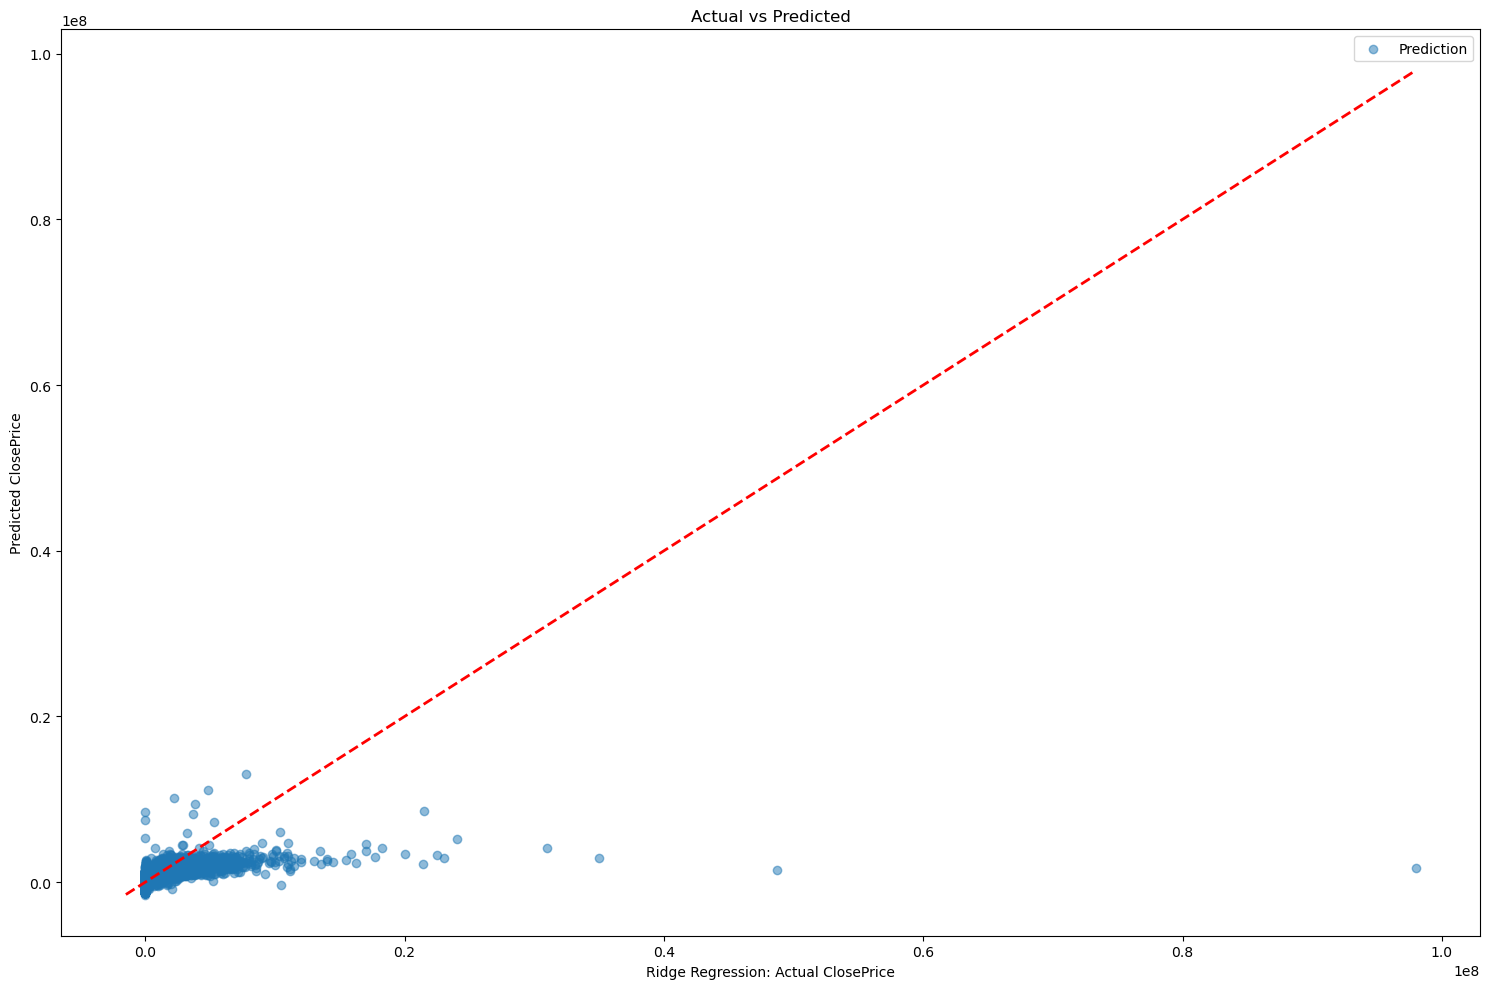

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Ridge Regression: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [28]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"Ridge Regression- Baseline model",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 47.23%
MAPE : 33.6863
R²   : 0.2850
MAE  : 482676.8067
MSE  : 1477916123840.2944
RMSE : 1215695.7365


## 3.2 Decision Tree Regressor

In [29]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np

model = DecisionTreeRegressor(max_depth=10,random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

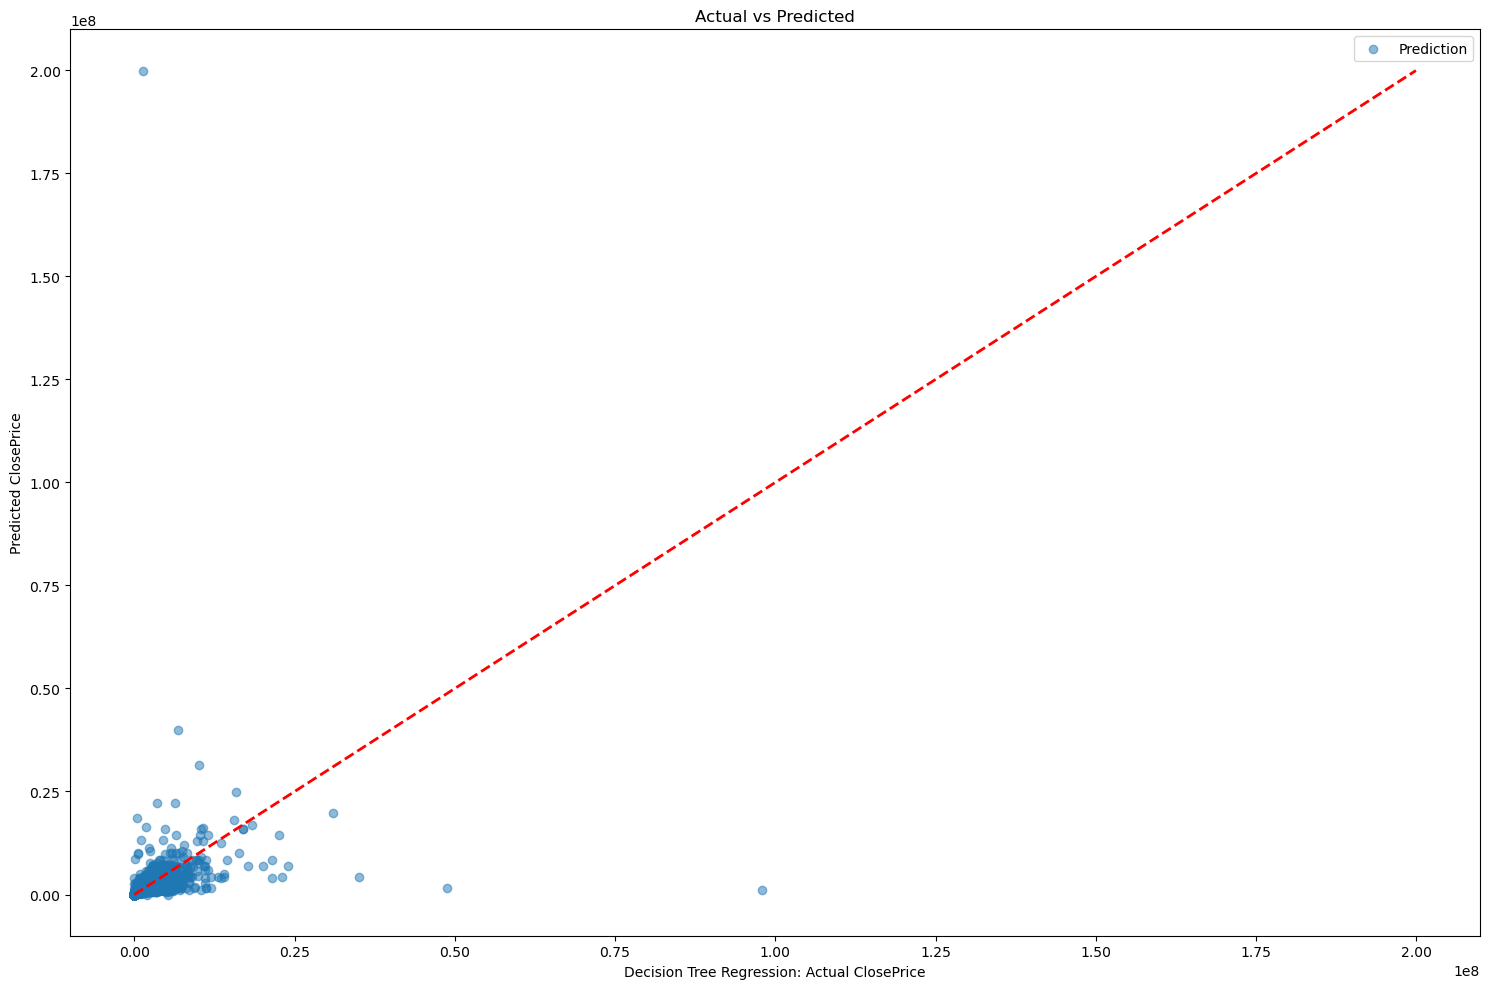

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Decision Tree Regression: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [31]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"Decision Tree Regressor",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 25.25%
MAPE : 0.5646
R²   : -0.6173
MAE  : 349782.6123
MSE  : 3343115621244.1006
RMSE : 1828418.8856


## 3.3 Random Forest Regressor

In [32]:
model = RandomForestRegressor(n_estimators=200,max_depth=15,random_state=42,n_jobs=-1)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

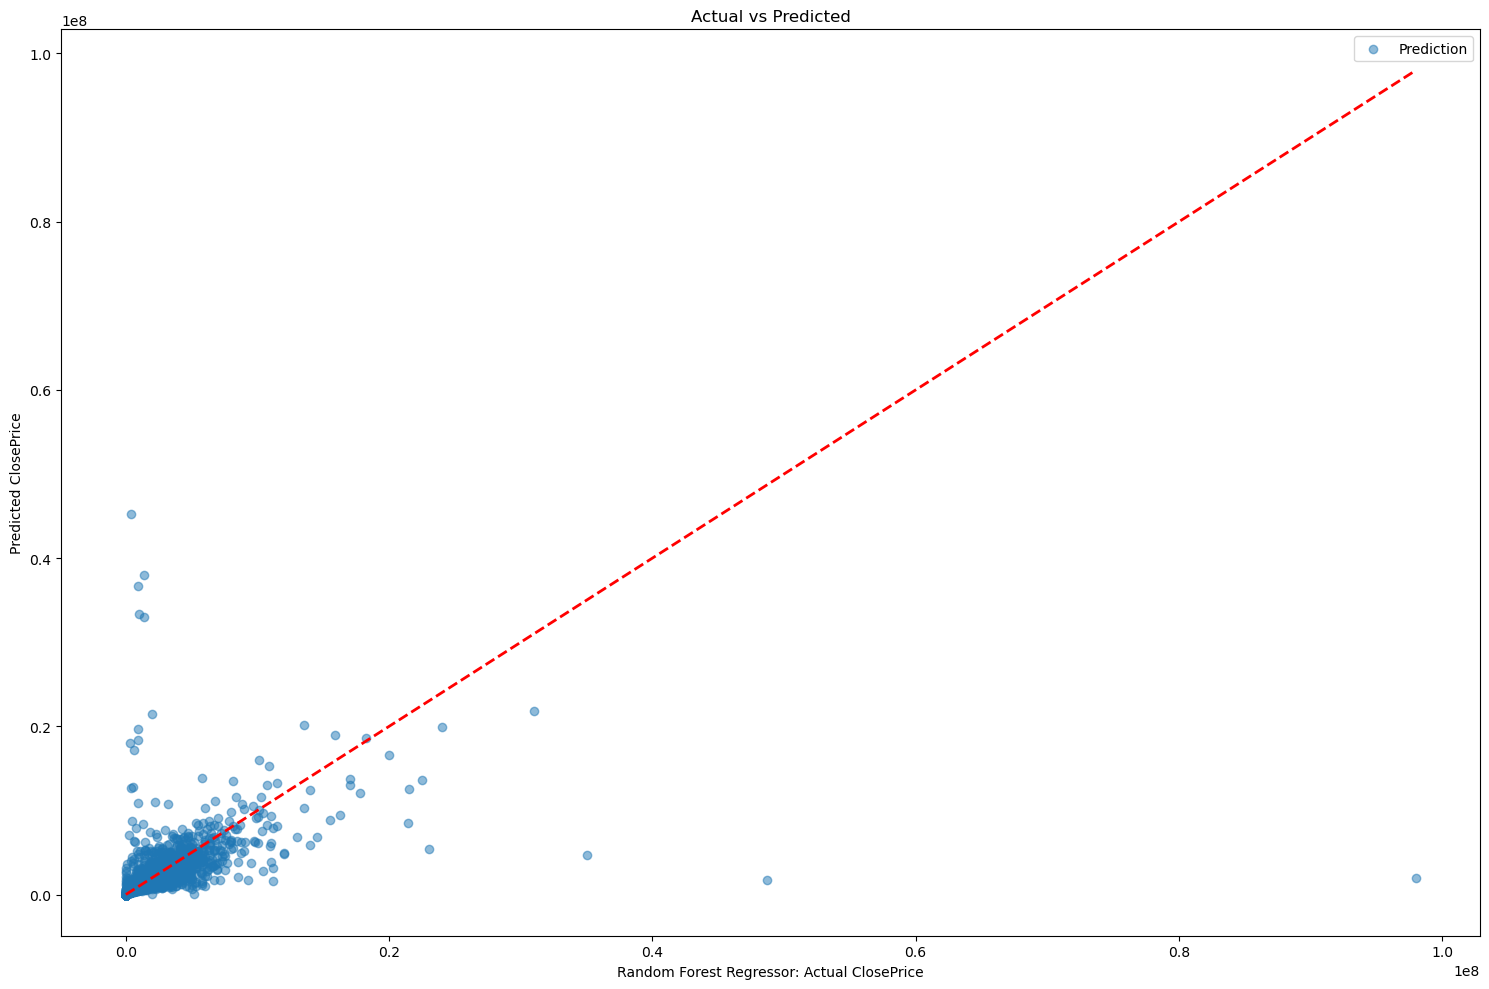

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Random Forest Regressor: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [34]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"Random Forest Regressor",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 16.49%
MAPE : 0.5449
R²   : 0.3251
MAE  : 250978.0248
MSE  : 1395058740182.5913
RMSE : 1181126.0475


## 3.4 XGBoost Regressor

In [35]:
from xgboost import XGBRegressor
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

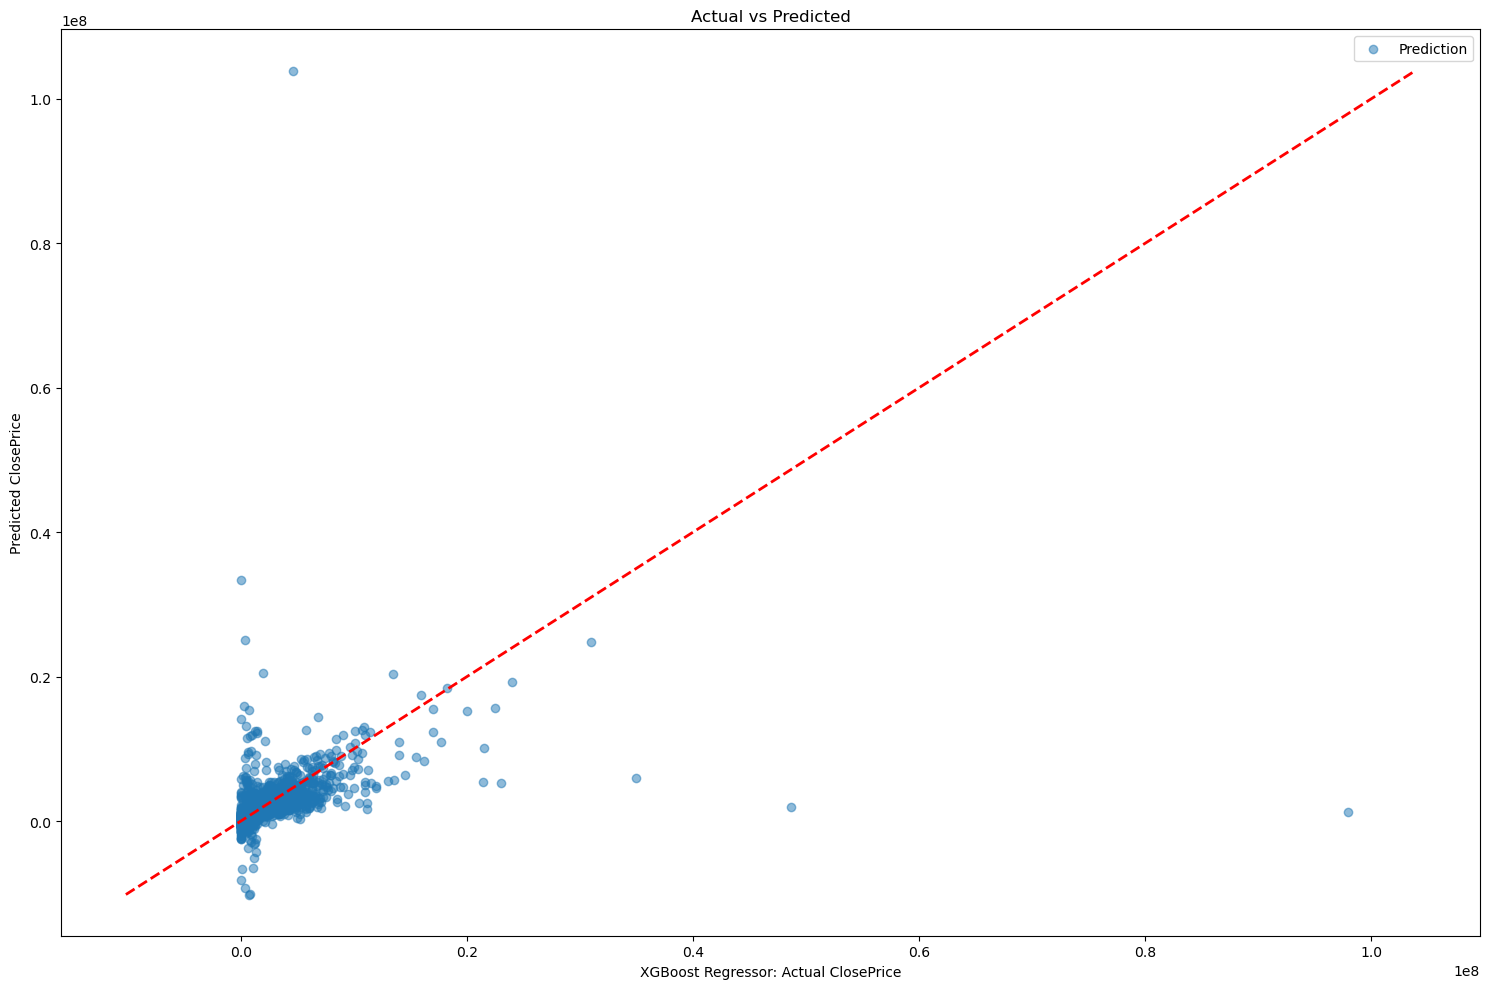

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("XGBoost Regressor: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [37]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"XGBoost Regressor",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 28.25%
MAPE : 7.0766
R²   : 0.1598
MAE  : 295552.6839
MSE  : 1736672271392.8120
RMSE : 1317828.6199


# 4. Rolling-Origin Backtesting


In [38]:
result_roll=[]

for X in range(4,12):
    months = sorted(data_clean["date_ym"].unique())
    data_train=data_clean[data_clean['date_ym'].isin(months[:X])]
    data_test=data_clean[data_clean['date_ym']==months[X]]
    cols=["CountyOrParish","City","StateOrProvince"]
    for col in cols:
       top10 = data_train[col].value_counts().nlargest(10).index
       data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
       data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
    data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
    data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
    # keep the cols consistently
    data_test = data_test.reindex(columns=data_train.columns, fill_value=0)
    X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_train["ClosePrice"]
    X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_test["ClosePrice"]

    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------Ridge regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"Ridge Regression",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })
    
    model = DecisionTreeRegressor(max_depth=10,random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------DecisionTree regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"Decision Tree Regression",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })

    model = RandomForestRegressor(n_estimators=200,max_depth=15,random_state=42,n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------Random Forest regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"Random Forest Regressor",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })

    model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------XGB Regressor regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"XGB Regressor",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })


    

C:\Users\23035\AppData\Local\Temp\ipykernel_58812\2612956520.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\2612956520.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\2612956520.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy 

--------------Ridge regression-------------
MdAPE: 72.06%
MAPE : 26.7979
R²   : 0.0022
MAE  : 841319.8380
MSE  : 257834083296220.8438
RMSE : 16057212.8122
--------------DecisionTree regression-------------
MdAPE: 24.33%
MAPE : 0.6199
R²   : -0.0152
MAE  : 647485.5293
MSE  : 262325534012682.9375
RMSE : 16196466.7138
--------------Random Forest regression-------------
MdAPE: 15.54%
MAPE : 0.4380
R²   : -0.0054
MAE  : 556143.5659
MSE  : 259808189749972.4375
RMSE : 16118566.6159
--------------XGB Regressor regression-------------
MdAPE: 26.34%
MAPE : 14.2129
R²   : -0.0576
MAE  : 635745.9177
MSE  : 273292661565422.3750
RMSE : 16531565.6114


C:\Users\23035\AppData\Local\Temp\ipykernel_58812\2612956520.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\2612956520.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\2612956520.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy 

--------------Ridge regression-------------
MdAPE: 89.02%
MAPE : 26.3816
R²   : 0.0097
MAE  : 662143.5738
MSE  : 52161104857305.1719
RMSE : 7222264.5242
--------------DecisionTree regression-------------
MdAPE: 25.84%
MAPE : 1.1480
R²   : -0.0065
MAE  : 415909.4583
MSE  : 53018877537888.9297
RMSE : 7281406.2885
--------------Random Forest regression-------------
MdAPE: 16.47%
MAPE : 0.9401
R²   : -0.0934
MAE  : 359550.8586
MSE  : 57593156571610.5703
RMSE : 7589015.5206
--------------XGB Regressor regression-------------
MdAPE: 30.92%
MAPE : 16.8919
R²   : -0.6240
MAE  : 485997.6695
MSE  : 85542105941075.8750
RMSE : 9248897.5527


C:\Users\23035\AppData\Local\Temp\ipykernel_58812\2612956520.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\2612956520.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\2612956520.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy 

...

--------------Ridge regression-------------
MdAPE: 63.20%
MAPE : 30.6556
R²   : 0.0103
MAE  : 566641.7474
MSE  : 59279247738138.3359
RMSE : 7699301.7695
--------------DecisionTree regression-------------
MdAPE: 26.23%
MAPE : 0.8446
R²   : 0.0115
MAE  : 435090.6490
MSE  : 59208609990861.1875
RMSE : 7694713.1195
--------------Random Forest regression-------------
MdAPE: 16.68%
MAPE : 7.1722
R²   : -0.1562
MAE  : 379626.9458
MSE  : 69253991987054.2891
RMSE : 8321898.3403
--------------XGB Regressor regression-------------
MdAPE: 33.62%
MAPE : 8.7687
R²   : -0.0475
MAE  : 436289.7399
MSE  : 62741951874877.4297
RMSE : 7920981.7494


C:\Users\23035\AppData\Local\Temp\ipykernel_58812\2612956520.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\2612956520.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\2612956520.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy 

--------------Ridge regression-------------
MdAPE: 62.36%
MAPE : 27.1043
R²   : 0.3676
MAE  : 500432.7318
MSE  : 1077669960646.7153
RMSE : 1038108.8385
--------------DecisionTree regression-------------
MdAPE: 27.30%
MAPE : 0.6274
R²   : -11.3169
MAE  : 388422.2667
MSE  : 20989699593090.1953
RMSE : 4581451.6906
--------------Random Forest regression-------------
MdAPE: 16.74%
MAPE : 0.6319
R²   : -3.7181
MAE  : 301237.8468
MSE  : 8040401350177.7676
RMSE : 2835560.1475
--------------XGB Regressor regression-------------
MdAPE: 31.59%
MAPE : 12.9493
R²   : -3.2601
MAE  : 393937.7537
MSE  : 7259807305056.8418
RMSE : 2694402.9589


C:\Users\23035\AppData\Local\Temp\ipykernel_58812\2612956520.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\2612956520.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\2612956520.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy 

--------------Ridge regression-------------
MdAPE: 56.96%
MAPE : 27.2412
R²   : 0.0151
MAE  : 575797.7566
MSE  : 54878729233679.9766
RMSE : 7408017.9018
--------------DecisionTree regression-------------
MdAPE: 25.60%
MAPE : 0.6556
R²   : 0.0113
MAE  : 429928.9325
MSE  : 55092505652636.6016
RMSE : 7422432.5967
--------------Random Forest regression-------------
MdAPE: 16.49%
MAPE : 0.5312
R²   : -0.0688
MAE  : 367503.7888
MSE  : 59554999408456.9844
RMSE : 7717188.5689
--------------XGB Regressor regression-------------
MdAPE: 30.36%
MAPE : 12.8171
R²   : -0.0571
MAE  : 444618.0619
MSE  : 58901276454096.8438
RMSE : 7674716.7019


# 5. Record the result

In [39]:
import pandas as pd

result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.to_csv("prediction_result_4.csv", index=True)
pd.DataFrame(results).to_csv("model_result_4.csv",index=True)
pd.DataFrame(result_roll).to_csv("model_result_roll_4.csv",index=True)

# 6. Report the result of comparsion between models

## Model Comparison

Four regression models were evaluated and compared using **R², MAE, RMSE, and MdAPE**. The results are summarized below.

| Model | R² | MAE | RMSE | MdAPE |
|------|------:|------:|------:|------:|
| Ridge Regression (Baseline) | 0.2850 | 482,676.81 | 1,215,695.74 | 47.23% |
| Decision Tree Regressor | -0.6173 | 349,782.61 | 1,828,418.89 | 25.25% |
| Random Forest Regressor | **0.3251** | **250,978.02** | **1,181,126.05** | **16.49%** |
| XGBoost Regressor | 0.1598 | 295,552.68 | 1,317,828.62 | 28.25% |

### Comparison with the Baseline

The Ridge Regression model was used as the baseline. Among all evaluated models, **Random Forest Regressor** achieved the best overall performance. It obtained the highest **R² score (0.3251)** while also producing the lowest **MAE, RMSE, and MdAPE**, indicating better predictive accuracy and stronger generalization than the baseline.

The **Decision Tree Regressor** produced a lower MAE than the Ridge baseline, but its **negative R² (-0.6173)** and the highest RMSE suggest that it overfitted the training data and generalized poorly to unseen samples.

The **XGBoost Regressor** achieved a positive R² score but did not outperform the Ridge Regression baseline. Although it reduced MAE compared with Ridge Regression, its overall predictive performance remained inferior to Random Forest.

Overall, **Random Forest Regressor** was selected as the best-performing model for this dataset.

---

## Model Behavior

### Ridge Regression (Baseline)

**Strengths**
- Simple and computationally efficient.
- Provides a strong linear baseline for comparison.
- Less prone to overfitting.

**Weaknesses**
- Assumes a linear relationship between features and sale prices.
- Cannot effectively model complex nonlinear feature interactions.

---

### Decision Tree Regressor

**Strengths**
- Easy to interpret.
- Naturally captures nonlinear relationships.
- Handles mixed feature types without extensive preprocessing.

**Weaknesses**
- Easily overfits the training data.
- Poor generalization performance, reflected by the negative R² score.
- High prediction variance.

---

### Random Forest Regressor

**Strengths**
- Achieved the best predictive performance among all evaluated models.
- Captures nonlinear relationships effectively.
- Reduces overfitting through ensemble learning.
- Produced the lowest prediction errors across all evaluation metrics.

**Weaknesses**
- More computationally expensive than linear models.
- Less interpretable than a single decision tree.

---

### XGBoost Regressor

**Strengths**
- Powerful boosting algorithm capable of modeling complex feature interactions.
- Performs well with appropriate hyperparameter tuning.

**Weaknesses**
- More sensitive to hyperparameter settings.
- Did not outperform Random Forest in the current experiment.
- Requires more tuning effort than the other evaluated models.

---

## Conclusion

Among the four evaluated models, **Random Forest Regressor** achieved the best overall performance. Compared with the Ridge Regression baseline, it improved the **R² score** from **0.2850** to **0.3251** while simultaneously reducing **MAE**, **RMSE**, and **MdAPE**. Therefore, Random Forest was selected as the final model for subsequent experiments.

# 7. Feature engineer

Example of sample features you can engineer: bed/bath ratio, age of property in years

# 8. Adding more detailed geographic layer using school districts

## 8.1 load the geographic

In [65]:
import geopandas as gpd
districts=gpd.read_file('DistrictAreas2526_-284845464123469011.geojson')
districts_filter=districts[districts["DistrictType"]=="Unified"]
districts_filter

,OBJECTID,Year,FedID,CDCode,CDSCode,CountyName,DistrictName,DistrictType,GradeLow,GradeHigh,...,MIGcount,MIGpct,SWDcount,SWDpct,SEDcount,SEDpct,DistrctAreaSqMi,LocaleCode,LocaleDesc,geometry
0,1,2025-26,0601770,0161119,01611190000000,Alameda,Alameda Unified,Unified,PK,12,...,0,0.0,1302,12.1,4259,39.5,11.248886,21,"21 - Suburban, Large","MULTIPOLYGON (((-13606222.82 4540862.699, -136..."
1,2,2025-26,0601860,0161127,01611270000000,Alameda,Albany City Unified,Unified,PK,12,...,0,0.0,363,9.7,1247,33.3,1.789975,21,"21 - Suburban, Large","POLYGON ((-13612893.866 4565099.707, -13612896..."
2,3,2025-26,0604740,0161143,01611430000000,Alameda,Berkeley Unified,Unified,PK,12,...,0,0.0,1118,11.9,2710,28.8,10.434281,12,"12 - City, Midsize","POLYGON ((-13609482.48 4565074.597, -13609483...."
3,4,2025-26,0607800,0161150,01611500000000,Alameda,Castro Valley Unified,Unified,PK,12,...,2,0.0,1186,12.2,3784,39.0,66.885261,21,"21 - Suburban, Large","MULTIPOLYGON (((-13582508.535 4529067.071, -13..."
4,5,2025-26,0612630,0161168,01611680000000,Alameda,Emery Unified,Unified,PK,12,...,0,0.0,98,16.1,407,66.7,1.273923,21,"21 - Suburban, Large","POLYGON ((-13613999.038 4555592.769, -13614126..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926,932,2025-26,0641580,5772694,57726940000000,Yolo,Washington Unified,Unified,PK,12,...,1,0.0,1242,15.1,3796,46.2,27.524200,13,"13 - City, Small","POLYGON ((-13538678.161 4660316.003, -13538674..."
927,933,2025-26,0642930,5772702,57727020000000,Yolo,Winters Joint Unified,Unified,PK,12,...,105,5.0,335,16.0,1185,56.7,126.903010,31,"31 - Town, Fringe","POLYGON ((-13578206.161 4668467.848, -13577796..."
928,934,2025-26,0643080,5772710,57727100000000,Yolo,Woodland Joint Unified,Unified,PK,12,...,296,3.2,1704,18.3,6827,73.4,309.459071,23,"23 - Suburban, Small","POLYGON ((-13580837.089 4696906.449, -13580814..."
930,936,2025-26,0624090,5872736,58727360000000,Yuba,Marysville Joint Unified,Unified,PK,12,...,47,0.4,1673,16.0,7648,73.2,462.497708,22,"22 - Suburban, Midsize","POLYGON ((-13540500.026 4756982.131, -13540491..."


In [66]:
districts_filter.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 345 entries, 0 to 934
Data columns (total 51 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   OBJECTID          345 non-null    int32   
 1   Year              345 non-null    object  
 2   FedID             345 non-null    object  
 3   CDCode            345 non-null    object  
 4   CDSCode           345 non-null    object  
 5   CountyName        345 non-null    object  
 6   DistrictName      345 non-null    object  
 7   DistrictType      345 non-null    object  
 8   GradeLow          345 non-null    object  
 9   GradeHigh         345 non-null    object  
 10  GradeLowCensus    345 non-null    object  
 11  GradeHighCensus   345 non-null    object  
 12  AssistStatus      345 non-null    object  
 13  UpdateNotes       133 non-null    object  
 14  EnrollTotal       345 non-null    int32   
 15  EnrollCharter     345 non-null    int32   
 16  EnrollNonCharter  

In [67]:
#points from the data
points=gpd.GeoDataFrame(data_clean,geometry=gpd.points_from_xy(data_clean["Longitude"],data_clean["Latitude"]), crs="EPSG:4326")

In [68]:
districts_filter = districts_filter.to_crs("EPSG:4326")

In [69]:
points=gpd.sjoin(points,districts_filter,how="left",predicate="within")#Left Join左连接 学区的数据

In [70]:
points.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 232951 entries, 0 to 232950
Data columns (total 74 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   ClosePrice                      232951 non-null  float64 
 1   Latitude                        232951 non-null  float64 
 2   Longitude                       232951 non-null  float64 
 3   LivingArea                      232951 non-null  float64 
 4   CountyOrParish                  232951 non-null  object  
 5   ParkingTotal                    232951 non-null  float64 
 6   PropertySubType                 232951 non-null  int64   
 7   LotSizeAcres                    232951 non-null  float64 
 8   YearBuilt                       232951 non-null  float64 
 9   StreetNumberNumeric             232951 non-null  float64 
 10  BathroomsTotalInteger           232951 non-null  float64 
 11  City                            232951 non-null  object  

# 9. Comparsion before vs after